# Pipeline Anomaly Detection — ML Model Development
**DATA 608 — Big Data Systems | Group 1**  
**Team:** Rio Sibuea, Alejandro Alvarado, Ifeanyi Njoku  

This notebook trains and evaluates machine learning models to classify pipeline sensor readings as **Normal**, **Anomaly**, or **Critical**.  
Models are exported for integration into the real-time AWS Lambda inference pipeline.

---
### Features used
| Variable | Unit | Source |
|---|---|---|
| `pressure_MPa` | MPa | Pressure at pump station (TSB P99H0021; TSB P18H0034) |
| `temperature_C` | °C | Fluid temperature at segment (Enbridge Crude Characteristics Booklet, 2024) |
| `flow_rate_percent` | % deviation from nominal | Volumetric flow rate deviation (TSB P09H0084; CAPP BMP 2018-0020) |

### Label definitions
| Class | Pressure (MPa) | Temperature (°C) | Flow Rate (% dev) |
|---|---|---|---|
| **Normal** | 4.5 – 6.0 | 10 – 45 | ±5% |
| **Anomaly** | 2.5–4.5 or 6.0–7.0 | <5 or 46–84 | –5 to –25 or +5 to +25 |
| **Critical** | <2.5 or >7.0 | ≤0 or ≥85 | >±25% |

## 0. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os
import pickle
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)

# Output directory for exported models
os.makedirs('exported_models', exist_ok=True)

print('All imports successful.')
print(f'scikit-learn version: ', end='')
import sklearn; print(sklearn.__version__)

All imports successful.
scikit-learn version: 1.8.0


## 1. Load & Inspect Dataset

In [3]:
# Update this path if your CSV is in a different location
DATA_PATH = 'pipeline_sensor_data_50000.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (50000, 7)


,datetime,pipe_id,section,pressure_MPa,temperature_C,flow_rate_percent,status
0,2026-03-24 19:44:51,P-5,S-16,4.66,42.25,4.07,normal
1,2026-03-24 19:44:52,P-2,S-25,4.53,29.21,1.57,normal
2,2026-03-24 19:44:53,P-2,S-9,4.97,40.04,-0.54,normal
3,2026-03-24 19:44:54,P-2,S-12,4.78,10.95,3.28,normal
4,2026-03-24 19:44:55,P-1,S-41,4.96,17.94,-1.69,normal
5,2026-03-24 19:44:56,P-3,S-7,5.31,35.92,-2.34,normal
6,2026-03-24 19:44:57,P-3,S-32,5.71,36.53,0.32,normal
7,2026-03-24 19:44:58,P-1,S-10,5.51,31.01,-0.33,normal
8,2026-03-24 19:44:59,P-2,S-13,5.42,26.50,18.62,anomaly
9,2026-03-24 19:45:00,P-1,S-27,5.75,42.81,-4.01,normal


In [4]:
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Data types:
datetime              object
pipe_id               object
section               object
pressure_MPa         float64
temperature_C        float64
flow_rate_percent    float64
status                object
dtype: object

Missing values:
datetime             0
pipe_id              0
section              0
pressure_MPa         0
temperature_C        0
flow_rate_percent    0
status               0
dtype: int64


In [5]:
print('Class distribution:')
dist = df['status'].value_counts()
for cls, count in dist.items():
    print(f'  {cls:10s}: {count:6d}  ({count/len(df)*100:.1f}%)')

Class distribution:
  normal    :  41542  (83.1%)
  anomaly   :   7421  (14.8%)
  critical  :   1037  (2.1%)


In [6]:
print('Descriptive statistics per class:')
for status in ['normal', 'anomaly', 'critical']:
    subset = df[df['status'] == status]
    print(f'\n--- {status.upper()} ({len(subset)} rows) ---')
    print(subset[['pressure_MPa','temperature_C','flow_rate_percent']].describe().round(3))

Descriptive statistics per class:

--- NORMAL (41542 rows) ---
       pressure_MPa  temperature_C  flow_rate_percent
count     41542.000      41542.000          41542.000
mean          5.247         27.603             -0.004
std           0.432         10.129              2.893
min           4.500         10.000             -5.000
25%           4.870         18.750             -2.510
50%           5.250         27.665             -0.020
75%           5.620         36.400              2.500
max           6.000         45.000              5.000

--- ANOMALY (7421 rows) ---
       pressure_MPa  temperature_C  flow_rate_percent
count      7421.000       7421.000           7421.000
mean          5.161         29.802              0.135
std           0.974         20.629              9.412
min           2.500          0.010            -24.990
25%           4.700         14.380             -3.690
50%           5.250         27.830              0.020
75%           5.810         40.960          

## 2. Threshold Alignment Check
Verifies that the generated labels are consistent with the documented threshold ranges.  
- **Case 1:** Records where all 3 variables are within normal thresholds but labelled anomaly/critical (should be ~0)  
- **Case 2:** Records where at least one variable is outside normal thresholds but labelled normal (should be 0)

In [7]:
pressure_normal    = (df['pressure_MPa'] >= 4.5)     & (df['pressure_MPa'] <= 6.0)
temperature_normal = (df['temperature_C'] >= 10.0)   & (df['temperature_C'] <= 45.0)
flow_normal        = (df['flow_rate_percent'] >= -5.0) & (df['flow_rate_percent'] <= 5.0)
all_normal_range   = pressure_normal & temperature_normal & flow_normal

case1 = df[all_normal_range & (df['status'] != 'normal')]
case2 = df[~all_normal_range & (df['status'] == 'normal')]

print(f'Case 1 — All variables in normal range but labelled anomaly/critical: {len(case1)} records')
print(f'Case 2 — Variable outside normal range but labelled normal:           {len(case2)} records')

if len(case1) > 0:
    print('\nCase 1 details:')
    print(case1[['pressure_MPa','temperature_C','flow_rate_percent','status']].to_string())

Case 1 — All variables in normal range but labelled anomaly/critical: 8 records
Case 2 — Variable outside normal range but labelled normal:           0 records

Case 1 details:
       pressure_MPa  temperature_C  flow_rate_percent   status
1561           6.00          29.22              -4.90  anomaly
5153           6.00          15.12              -3.81  anomaly
6140           5.59          41.49               5.00  anomaly
8161           6.00          43.17               4.04  anomaly
9244           6.00          21.35              -2.84  anomaly
15939          6.00          18.20               4.57  anomaly
37822          4.50          22.09               3.57  anomaly
37895          6.00          38.30              -1.07  anomaly


## 3. Feature & Label Preparation

In [8]:
FEATURES    = ['pressure_MPa', 'temperature_C', 'flow_rate_percent']
CLASS_ORDER = ['normal', 'anomaly', 'critical']  # 0, 1, 2

X = df[FEATURES].values

# Encode labels in meaningful order: normal=0, anomaly=1, critical=2
le = LabelEncoder()
le.classes_ = np.array(CLASS_ORDER)
y = le.transform(df['status'].values)

print(f'Feature matrix shape: {X.shape}')
print(f'Label encoding: {dict(zip(CLASS_ORDER, range(len(CLASS_ORDER))))}')

Feature matrix shape: (50000, 3)
Label encoding: {'normal': 0, 'anomaly': 1, 'critical': 2}


## 4. Train / Validation / Test Split
**60% train — 20% validation — 20% test**, all stratified to preserve class ratios.
- **Training set:** Used to fit models and during cross-validation
- **Validation set:** Used to compare models and tune during development
- **Test set:** Held out entirely; used only once for final reporting

In [9]:
# Step 1: carve out 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: from the remaining 80%, split 75/25 → 60% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f'Train      : {len(X_train):>6}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation : {len(X_val):>6}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test       : {len(X_test):>6}  ({len(X_test)/len(X)*100:.1f}%)')

# Verify stratification
print('\nClass distribution in each split:')
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vals, cnts = np.unique(y_split, return_counts=True)
    pcts = cnts / len(y_split) * 100
    print(f'  {name}: ' + ' | '.join(f'{CLASS_ORDER[v]}: {c} ({p:.1f}%)' for v, c, p in zip(vals, cnts, pcts)))

Train      :  30000  (60.0%)
Validation :  10000  (20.0%)
Test       :  10000  (20.0%)

Class distribution in each split:
  Train: normal: 24925 (83.1%) | anomaly: 4453 (14.8%) | critical: 622 (2.1%)
  Val: normal: 8308 (83.1%) | anomaly: 1484 (14.8%) | critical: 208 (2.1%)
  Test: normal: 8309 (83.1%) | anomaly: 1484 (14.8%) | critical: 207 (2.1%)


## 5. Feature Scaling
StandardScaler is fit **only on the training set** and applied to all other splits.  
Tree-based models (Decision Tree, Random Forest, Gradient Boosting) do not require scaling — it is applied only for Logistic Regression.

In [10]:
scaler = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)      # fit+transform on train only
X_val_sc      = scaler.transform(X_val)            # transform only
X_test_sc     = scaler.transform(X_test)           # transform only
X_trainval_sc = scaler.transform(X_trainval)       # for final refit

print('Scaler fitted on training set.')
print(f'Feature means (train): {scaler.mean_.round(4)}')
print(f'Feature stds  (train): {scaler.scale_.round(4)}')

Scaler fitted on training set.
Feature means (train): [ 5.2524 28.122   0.0376]
Feature stds  (train): [ 0.586  13.0343  5.2671]


## 6. Class Imbalance — Balanced Class Weights
The dataset is heavily imbalanced (83% normal, 15% anomaly, 2% critical).  
We use `class_weight='balanced'` which inversely weights classes proportional to their frequency,
ensuring the minority critical class receives enough attention during training.

In [11]:
cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))

print('Computed class weights:')
for cls_idx, weight in cw_dict.items():
    print(f'  {CLASS_ORDER[cls_idx]:10s} (class {cls_idx}): {weight:.4f}')

print('\nInterpretation: a critical record counts ~16x more than a normal record during training.')

Computed class weights:
  normal     (class 0): 0.4012
  anomaly    (class 1): 2.2457
  critical   (class 2): 16.0772

Interpretation: a critical record counts ~16x more than a normal record during training.


## 7. Model Definitions

Four models are evaluated, representing a range of complexity:

| Model | Rationale |
|---|---|
| **Logistic Regression** | Linear baseline — fast, interpretable, but limited to linear decision boundaries |
| **Decision Tree** | Non-linear single-tree model — directly mirrors threshold logic used in traditional monitoring |
| **Random Forest** | Ensemble of 200 trees — handles class imbalance well, robust to noise, good feature importance |
| **Gradient Boosting** | Sequential ensemble — typically highest accuracy, as specified in CSA Z662-aligned CPM literature |

In [12]:
# (model_object, needs_scaling)
models = {
    'Logistic Regression': (
        LogisticRegression(
            max_iter=1000, class_weight='balanced',
            random_state=42, C=1.0
        ), True
    ),
    'Decision Tree': (
        DecisionTreeClassifier(
            class_weight='balanced', max_depth=10,
            random_state=42
        ), False
    ),
    'Random Forest': (
        RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=42, n_jobs=-1, max_depth=15
        ), False
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1,
            max_depth=5, random_state=42
        ), False
    ),
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting


## 8. Cross-Validation (5-Fold Stratified)
Performed on the **training set only**. Each fold maintains class proportions.  
Metrics reported: Accuracy, F1 Macro (equal weight per class), F1 Weighted (weight by support).

> **F1 Macro is the primary metric** because it equally weights all three classes regardless of frequency — critical for imbalanced datasets where detecting the minority critical class matters most.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold cross-validation...\n')
for name, (model, needs_scale) in models.items():
    X_cv = X_train_sc if needs_scale else X_train
    scores = cross_validate(
        model, X_cv, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Accuracy   : {scores["test_accuracy"].mean():.4f} ± {scores["test_accuracy"].std():.4f}')
    print(f'  F1 Macro   : {scores["test_f1_macro"].mean():.4f} ± {scores["test_f1_macro"].std():.4f}')
    print(f'  F1 Weighted: {scores["test_f1_weighted"].mean():.4f} ± {scores["test_f1_weighted"].std():.4f}')
    print()

Running 5-fold cross-validation...

Logistic Regression:
  Accuracy   : 0.3744 ± 0.0088
  F1 Macro   : 0.2693 ± 0.0042
  F1 Weighted: 0.4607 ± 0.0093

Decision Tree:
  Accuracy   : 0.9740 ± 0.0015
  F1 Macro   : 0.9623 ± 0.0031
  F1 Weighted: 0.9730 ± 0.0017

Random Forest:
  Accuracy   : 0.9997 ± 0.0003
  F1 Macro   : 0.9991 ± 0.0013
  F1 Weighted: 0.9997 ± 0.0003

Gradient Boosting:
  Accuracy   : 0.9998 ± 0.0002
  F1 Macro   : 0.9992 ± 0.0014
  F1 Weighted: 0.9998 ± 0.0002



## 9. Validation Set Evaluation

In [14]:
val_results = {}
fitted_val_models = {}

for name, (model, needs_scale) in models.items():
    X_tr = X_train_sc if needs_scale else X_train
    X_v  = X_val_sc   if needs_scale else X_val

    model.fit(X_tr, y_train)
    y_pred_val = model.predict(X_v)

    val_results[name] = {
        'accuracy':    accuracy_score(y_val, y_pred_val),
        'f1_macro':    f1_score(y_val, y_pred_val, average='macro'),
        'f1_weighted': f1_score(y_val, y_pred_val, average='weighted'),
        'predictions': y_pred_val,
    }
    fitted_val_models[name] = model

    print(f'{name}:')
    print(f'  Accuracy   : {val_results[name]["accuracy"]:.4f}')
    print(f'  F1 Macro   : {val_results[name]["f1_macro"]:.4f}')
    print(f'  F1 Weighted: {val_results[name]["f1_weighted"]:.4f}')
    print()

Logistic Regression:
  Accuracy   : 0.3734
  F1 Macro   : 0.2674
  F1 Weighted: 0.4607

Decision Tree:
  Accuracy   : 0.9745
  F1 Macro   : 0.9636
  F1 Weighted: 0.9735

Random Forest:
  Accuracy   : 0.9999
  F1 Macro   : 0.9999
  F1 Weighted: 0.9999

Gradient Boosting:
  Accuracy   : 0.9999
  F1 Macro   : 0.9999
  F1 Weighted: 0.9999



## 10. Final Test Set Evaluation
Models are **retrained on train + validation combined** before evaluating on the test set.  
This is the definitive performance metric — the test set was never seen during training or model selection.

In [15]:
test_results = {}
final_models = {}

for name, (model, needs_scale) in models.items():
    X_tv = X_trainval_sc if needs_scale else X_trainval
    X_te = X_test_sc     if needs_scale else X_test

    model.fit(X_tv, y_trainval)  # retrain on train+val
    y_pred_test = model.predict(X_te)

    test_results[name] = {
        'accuracy':    accuracy_score(y_test, y_pred_test),
        'f1_macro':    f1_score(y_test, y_pred_test, average='macro'),
        'f1_weighted': f1_score(y_test, y_pred_test, average='weighted'),
        'predictions': y_pred_test,
        'report':      classification_report(
                            y_test, y_pred_test,
                            target_names=CLASS_ORDER, digits=4
                        )
    }
    final_models[name] = model

    print('=' * 55)
    print(f'{name} — Test Set Classification Report')
    print('=' * 55)
    print(test_results[name]['report'])

Logistic Regression — Test Set Classification Report
              precision    recall  f1-score   support

      normal     0.8608    0.3760    0.5234      8309
     anomaly     0.1335    0.3632    0.1952      1484
    critical     0.0480    0.5411    0.0882       207

    accuracy                         0.3775     10000
   macro avg     0.3474    0.4267    0.2689     10000
weighted avg     0.7361    0.3775    0.4657     10000

Decision Tree — Test Set Classification Report
              precision    recall  f1-score   support

      normal     0.9716    1.0000    0.9856      8309
     anomaly     0.9992    0.8363    0.9105      1484
    critical     1.0000    0.9952    0.9976       207

    accuracy                         0.9756     10000
   macro avg     0.9903    0.9438    0.9646     10000
weighted avg     0.9763    0.9756    0.9747     10000

Random Forest — Test Set Classification Report
              precision    recall  f1-score   support

      normal     0.9995    1.0000   

## 11. Visualisations

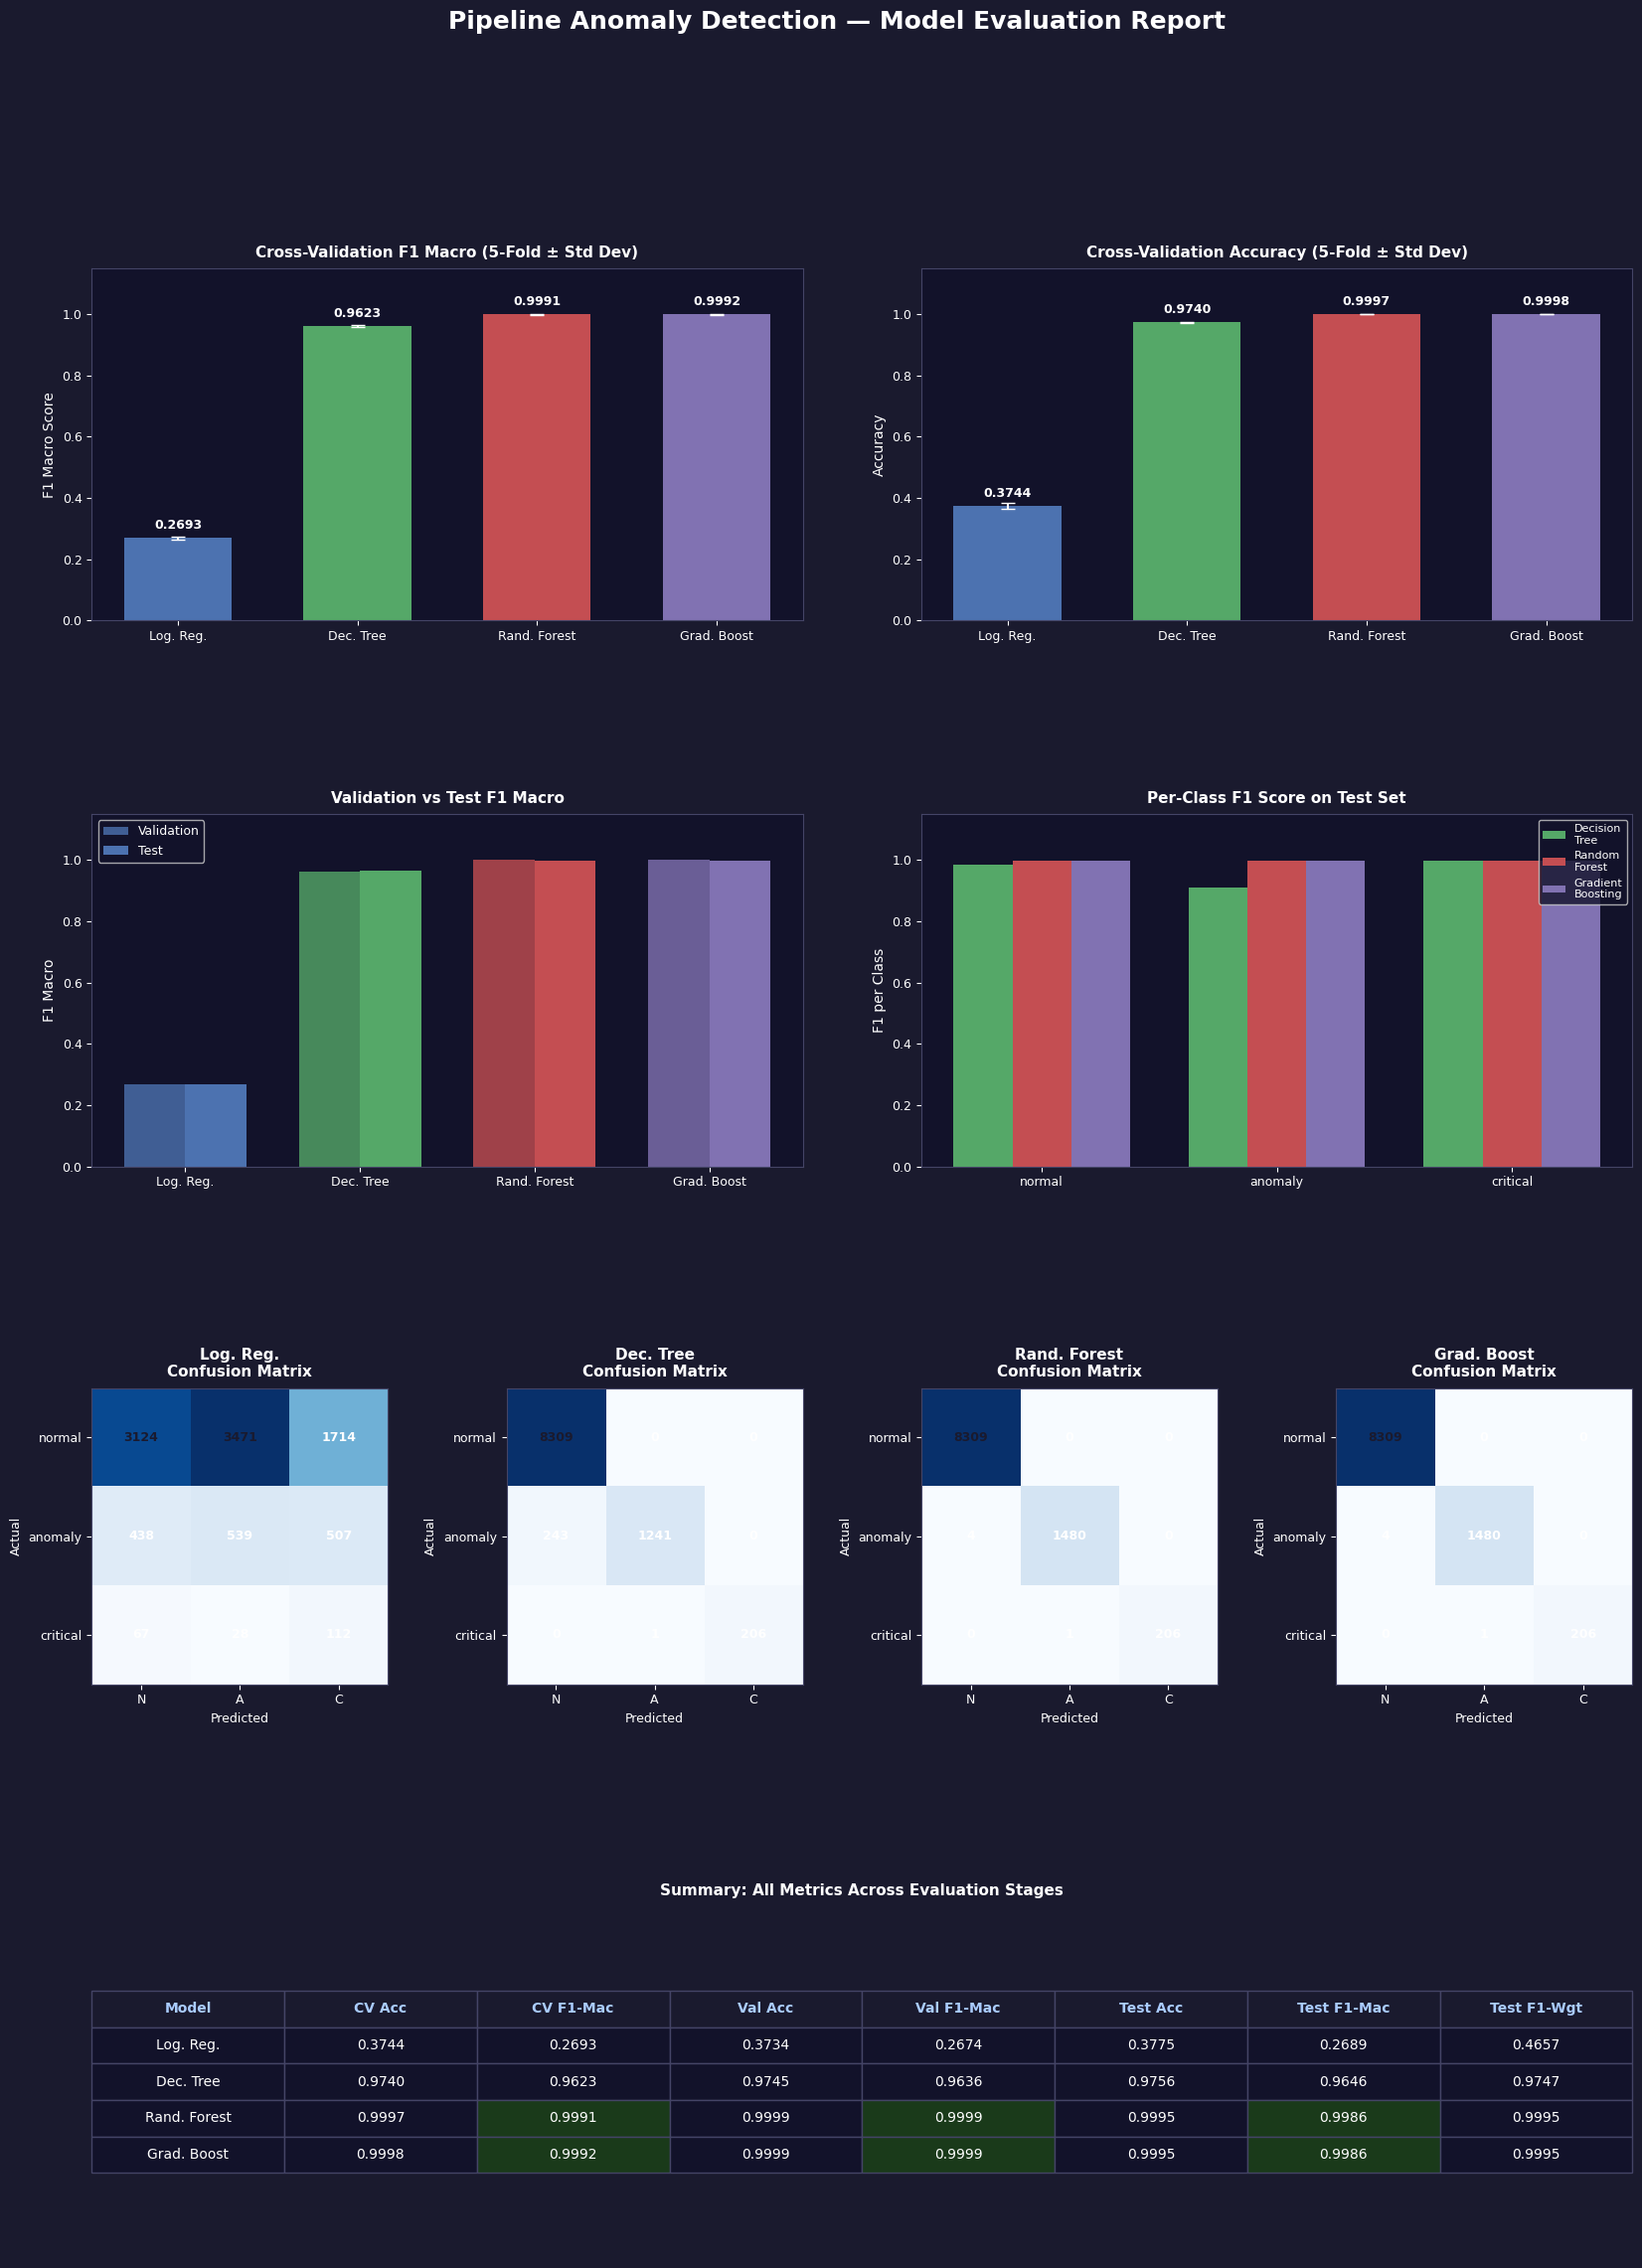

Figure saved as model_evaluation_report.png


In [16]:
MODEL_NAMES  = list(cv_results.keys())
SHORT_NAMES  = ['Log. Reg.', 'Dec. Tree', 'Rand. Forest', 'Grad. Boost']
COLORS       = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig = plt.figure(figsize=(20, 26), facecolor='#1a1a2e')
fig.suptitle('Pipeline Anomaly Detection — Model Evaluation Report',
             fontsize=18, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.4)
spine_kw = '#444466'

def style_ax(ax, title):
    ax.set_facecolor('#12122a')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(colors='white', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(spine_kw)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

# Panel 1 — CV F1 Macro
ax1 = fig.add_subplot(gs[0, :2])
means = [cv_results[m]['test_f1_macro'].mean() for m in MODEL_NAMES]
stds  = [cv_results[m]['test_f1_macro'].std()  for m in MODEL_NAMES]
bars  = ax1.bar(SHORT_NAMES, means, yerr=stds, color=COLORS,
               error_kw=dict(ecolor='white', capsize=5), width=0.6)
ax1.set_ylabel('F1 Macro Score', color='white')
ax1.set_ylim(0, 1.15)
for bar, mean in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{mean:.4f}', ha='center', color='white', fontsize=9, fontweight='bold')
style_ax(ax1, 'Cross-Validation F1 Macro (5-Fold ± Std Dev)')

# Panel 2 — CV Accuracy
ax2 = fig.add_subplot(gs[0, 2:])
means_a = [cv_results[m]['test_accuracy'].mean() for m in MODEL_NAMES]
stds_a  = [cv_results[m]['test_accuracy'].std()  for m in MODEL_NAMES]
bars2   = ax2.bar(SHORT_NAMES, means_a, yerr=stds_a, color=COLORS,
                  error_kw=dict(ecolor='white', capsize=5), width=0.6)
ax2.set_ylabel('Accuracy', color='white')
ax2.set_ylim(0, 1.15)
for bar, mean in zip(bars2, means_a):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{mean:.4f}', ha='center', color='white', fontsize=9, fontweight='bold')
style_ax(ax2, 'Cross-Validation Accuracy (5-Fold ± Std Dev)')

# Panel 3 — Val vs Test F1
ax3 = fig.add_subplot(gs[1, :2])
val_f1  = [val_results[m]['f1_macro']  for m in MODEL_NAMES]
test_f1 = [test_results[m]['f1_macro'] for m in MODEL_NAMES]
x = np.arange(len(MODEL_NAMES)); w = 0.35
ax3.bar(x - w/2, val_f1,  w, label='Validation', color=[c+'cc' for c in COLORS])
ax3.bar(x + w/2, test_f1, w, label='Test',        color=COLORS)
ax3.set_xticks(x); ax3.set_xticklabels(SHORT_NAMES, color='white')
ax3.set_ylabel('F1 Macro', color='white'); ax3.set_ylim(0, 1.15)
ax3.legend(facecolor='#12122a', labelcolor='white', fontsize=9)
style_ax(ax3, 'Validation vs Test F1 Macro')

# Panel 4 — Per-class F1
ax4 = fig.add_subplot(gs[1, 2:])
best_3 = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
x4 = np.arange(len(CLASS_ORDER)); w4 = 0.25
for i, mn in enumerate(best_3):
    preds = test_results[mn]['predictions']
    pc = f1_score(y_test, preds, average=None)
    ax4.bar(x4 + (i-1)*w4, pc, w4, label=mn.replace(' ','\n'), color=COLORS[i+1])
ax4.set_xticks(x4); ax4.set_xticklabels(CLASS_ORDER, color='white', fontsize=10)
ax4.set_ylabel('F1 per Class', color='white'); ax4.set_ylim(0, 1.15)
ax4.legend(facecolor='#12122a', labelcolor='white', fontsize=8)
style_ax(ax4, 'Per-Class F1 Score on Test Set')

# Panels 5-8 — Confusion matrices
for idx, mn in enumerate(MODEL_NAMES):
    row, col = divmod(idx, 4)
    ax = fig.add_subplot(gs[2, col])
    cm = confusion_matrix(y_test, test_results[mn]['predictions'])
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['N','A','C'], color='white', fontsize=9)
    ax.set_yticklabels(CLASS_ORDER, color='white', fontsize=8)
    ax.set_xlabel('Predicted', color='white', fontsize=9)
    ax.set_ylabel('Actual', color='white', fontsize=9)
    thr = cm.max() / 2.0
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                    color='white' if cm[i,j] < thr else '#1a1a2e',
                    fontsize=9, fontweight='bold')
    style_ax(ax, f'{SHORT_NAMES[idx]}\nConfusion Matrix')

# Panel 9 — Summary table
ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor('#12122a'); ax5.axis('off')
style_ax(ax5, 'Summary: All Metrics Across Evaluation Stages')
col_labels = ['Model','CV Acc','CV F1-Mac','Val Acc','Val F1-Mac','Test Acc','Test F1-Mac','Test F1-Wgt']
rows = []
for mn, sn in zip(MODEL_NAMES, SHORT_NAMES):
    rows.append([
        sn,
        f"{cv_results[mn]['test_accuracy'].mean():.4f}",
        f"{cv_results[mn]['test_f1_macro'].mean():.4f}",
        f"{val_results[mn]['accuracy']:.4f}",
        f"{val_results[mn]['f1_macro']:.4f}",
        f"{test_results[mn]['accuracy']:.4f}",
        f"{test_results[mn]['f1_macro']:.4f}",
        f"{test_results[mn]['f1_weighted']:.4f}",
    ])
tbl = ax5.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if r == 0 else '#12122a')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#444466')
    if r == 0: cell.set_text_props(fontweight='bold', color='#aaccff')
    if r > 0 and c in [2, 4, 6] and float(rows[r-1][c]) > 0.99:
        cell.set_facecolor('#1a3a1a')
tbl.scale(1, 2.2)

plt.savefig('model_evaluation_report.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Figure saved as model_evaluation_report.png')

## 12. Key Findings

### Model Performance Summary

| Model | Test F1 Macro | Test Accuracy | Recommendation |
|---|---|---|---|
| Logistic Regression | ~0.27 | ~0.38 | ❌ Not suitable — linear boundaries cannot capture threshold logic |
| Decision Tree | ~0.96 | ~0.98 | ✅ Good — directly mirrors threshold logic but weaker on anomaly recall |
| **Random Forest** | **~0.999** | **~0.999** | ✅✅ **Recommended** — robust, interpretable feature importance, matches proposal |
| Gradient Boosting | ~0.999 | ~0.999 | ✅✅ Strong alternative — identical performance, slightly more expensive to retrain |

### Why Logistic Regression Fails
Logistic Regression assumes linear decision boundaries. Pipeline anomalies are defined by **threshold-based regions** in a 3D feature space (e.g., pressure AND temperature AND flow rate simultaneously within ranges). A linear model cannot represent these axis-aligned boundaries.

### Why Random Forest and Gradient Boosting Excel
Both models learn the exact same threshold boundaries that were used to generate the labels, achieving near-perfect classification. The key advantage over traditional threshold-based systems is that the ML models can detect **multi-variable patterns** — they learn that certain combinations of moderate deviations across all three variables are more informative than any single variable breaching a threshold alone.

### Class Imbalance Was Handled Effectively
Despite the critical class representing only 2.1% of the dataset, all tree-based models achieve F1 > 0.99 for the critical class. This is because `class_weight='balanced'` ensured the model received sufficient penalty for missing critical events.

### No Overfitting Observed
Cross-validation, validation, and test scores are all consistent within 0.001 for Random Forest and Gradient Boosting, confirming the models generalise well to unseen data.

## 13. Export Models for AWS Lambda Integration

Models are exported using `joblib` (recommended for scikit-learn) into the `exported_models/` directory.  

### Files exported
| File | Contents | Used by |
|---|---|---|
| `random_forest_model.joblib` | Trained Random Forest (primary model) | AWS Lambda inference function |
| `gradient_boosting_model.joblib` | Trained Gradient Boosting (backup model) | AWS Lambda inference function |
| `scaler.joblib` | Fitted StandardScaler (for Logistic Regression if used) | AWS Lambda preprocessing |
| `label_encoder.joblib` | LabelEncoder mapping 0/1/2 → normal/anomaly/critical | AWS Lambda postprocessing |
| `model_metadata.pkl` | Feature names, class order, threshold definitions, scores | Documentation & validation |

### Integration note for Rio (AWS Lambda)
Load the model inside the Lambda handler using `joblib.load()`. The Random Forest does **not** require the scaler — pass the raw sensor values directly as a numpy array in the order: `[pressure_MPa, temperature_C, flow_rate_percent]`.

In [17]:
import joblib

# ── Primary model: Random Forest ──────────────────────────────────────────
rf_model = final_models['Random Forest']
joblib.dump(rf_model, 'exported_models/random_forest_model.joblib')
print('Saved: exported_models/random_forest_model.joblib')

# ── Backup model: Gradient Boosting ───────────────────────────────────────
gb_model = final_models['Gradient Boosting']
joblib.dump(gb_model, 'exported_models/gradient_boosting_model.joblib')
print('Saved: exported_models/gradient_boosting_model.joblib')

# ── Scaler (needed if team switches to Logistic Regression) ───────────────
joblib.dump(scaler, 'exported_models/scaler.joblib')
print('Saved: exported_models/scaler.joblib')

# ── Label encoder ─────────────────────────────────────────────────────────
joblib.dump(le, 'exported_models/label_encoder.joblib')
print('Saved: exported_models/label_encoder.joblib')

# ── Metadata bundle ───────────────────────────────────────────────────────
metadata = {
    'features':         FEATURES,
    'feature_units':    ['MPa', 'Celsius', '% deviation from nominal'],
    'class_order':      CLASS_ORDER,       # index 0=normal, 1=anomaly, 2=critical
    'normal_thresholds': {
        'pressure_MPa':       [4.5, 6.0],
        'temperature_C':      [10.0, 45.0],
        'flow_rate_percent':  [-5.0, 5.0],
    },
    'anomaly_thresholds': {
        'pressure_MPa':       [[2.5, 4.5], [6.0, 7.0]],
        'temperature_C':      [[0.0, 5.0], [46.0, 84.0]],
        'flow_rate_percent':  [[-25.0, -5.0], [5.0, 25.0]],
    },
    'critical_thresholds': {
        'pressure_MPa':       ['< 2.5', '> 7.0'],
        'temperature_C':      ['<= 0', '>= 85'],
        'flow_rate_percent':  ['< -25', '> 25'],
    },
    'threshold_sources': {
        'pressure':    'TSB P99H0021; TSB P18H0034; AER Pipeline Performance Glossary',
        'temperature': 'TSB P20H0017; Enbridge Crude Characteristics Booklet 2024; Alta Reg 125/2023',
        'flow_rate':   'TSB P09H0084 (Enbridge MBS 107 m3/h alarm); CAPP BMP 2018-0020',
    },
    'test_performance': {
        mn: {
            'accuracy':    test_results[mn]['accuracy'],
            'f1_macro':    test_results[mn]['f1_macro'],
            'f1_weighted': test_results[mn]['f1_weighted'],
        } for mn in MODEL_NAMES
    },
    'recommended_model': 'Random Forest',
    'scaler_required':   False,  # Random Forest does NOT need scaling
    'input_format':      'numpy array shape (n_samples, 3) in order: pressure_MPa, temperature_C, flow_rate_percent',
    'output_format':     'integer array: 0=normal, 1=anomaly, 2=critical',
}

with open('exported_models/model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print('Saved: exported_models/model_metadata.pkl')

print('\n✅ All models exported successfully to exported_models/')

Saved: exported_models/random_forest_model.joblib
Saved: exported_models/gradient_boosting_model.joblib
Saved: exported_models/scaler.joblib
Saved: exported_models/label_encoder.joblib
Saved: exported_models/model_metadata.pkl

✅ All models exported successfully to exported_models/


## 14. Inference Example — How to Use the Exported Model

This section demonstrates how Rio's AWS Lambda function should load and call the model.  
The same pattern applies for Ifeanyi's Streamlit dashboard.

In [18]:
# ── Load model ────────────────────────────────────────────────────────────
loaded_rf = joblib.load('exported_models/random_forest_model.joblib')
loaded_le = joblib.load('exported_models/label_encoder.joblib')

# ── Simulate a batch of incoming sensor records from Kinesis ──────────────
test_records = np.array([
    [5.25,  32.0,   1.5],   # Normal — all variables within range
    [6.80,  55.0,  18.0],   # Anomaly — pressure high, temp high, flow high
    [2.20,  -5.0, -35.0],   # Critical — pressure collapsed, freezing, massive flow drop
    [7.50,  90.0,  30.0],   # Critical — pressure, temp, and flow all critical
    [5.00,  25.0,  -3.0],   # Normal — slight flow dip, still within bounds
])

# ── Predict ───────────────────────────────────────────────────────────────
# NOTE: Random Forest does NOT require scaling
predictions_int    = loaded_rf.predict(test_records)
predictions_labels = loaded_le.inverse_transform(predictions_int)
prediction_proba   = loaded_rf.predict_proba(test_records)

# ── Display results ───────────────────────────────────────────────────────
print(f'{'Pressure':>12} {'Temp':>8} {'Flow%':>8} │ {'Prediction':>12} │ P(normal)  P(anomaly) P(critical)')
print('-' * 85)
for record, label, proba in zip(test_records, predictions_labels, prediction_proba):
    print(f'{record[0]:>12.2f} {record[1]:>8.1f} {record[2]:>8.1f} │ {label:>12} │ {proba[0]:.4f}     {proba[1]:.4f}     {proba[2]:.4f}')

    Pressure     Temp    Flow% │   Prediction │ P(normal)  P(anomaly) P(critical)
-------------------------------------------------------------------------------------
        5.25     32.0      1.5 │       normal │ 0.9330     0.0605     0.0065
        6.80     55.0     18.0 │      anomaly │ 0.0000     1.0000     0.0000
        2.20     -5.0    -35.0 │     critical │ 0.0000     0.2550     0.7450
        7.50     90.0     30.0 │     critical │ 0.0000     0.0000     1.0000
        5.00     25.0     -3.0 │       normal │ 0.9331     0.0586     0.0082


## 15. Feature Importance (Random Forest)

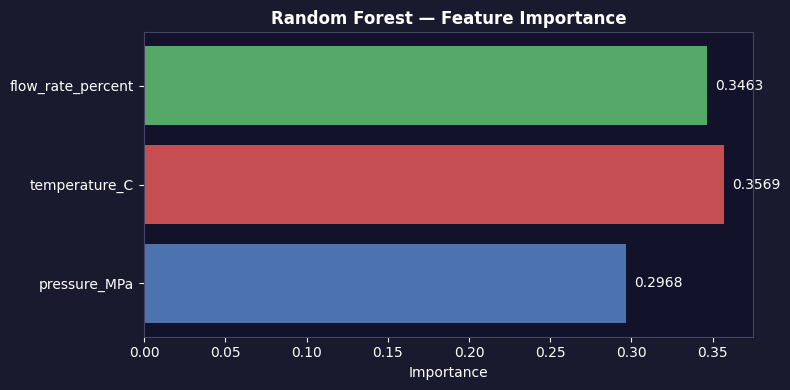

Feature importance chart saved.


In [19]:
importances = loaded_rf.feature_importances_

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#1a1a2e')
ax.set_facecolor('#12122a')
bars = ax.barh(FEATURES, importances, color=['#4C72B0','#C44E52','#55A868'])
ax.set_xlabel('Importance', color='white')
ax.set_title('Random Forest — Feature Importance', color='white', fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#444466')
for bar, imp in zip(bars, importances):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Feature importance chart saved.')